<a href="https://colab.research.google.com/github/Diana-Sheng/CB2330_Project_Group10/blob/main/Project_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Card**
**_The paper:_** Assessing reliability and accuracy of qPCR, dPCR and ddPCR for estimating mitochondrial DNA copy number in songbird blood and sperm cells

**_The data object:_** the Coefficient of Variation (CV) and Dilution Step data in Table1.

**_The random variable chosen:_** Observed number of empty partitions and the estimated concentrations of DNA, which support the calculation of Coefficient of Variation (CV) under different dilution steps and between dPCR and ddPCR.

**_What the paper does:_** compare the _reliability and accuracy_ of dPCR and ddPCR to quantify low and high concentration of DNA using CVs.

**_The generative model proposed:_**  
1)Poisson Model based on physical partitions: DNA molecules randomly drop into K partitions independently, where K equals to 8050 or 16082;

2)${P(X=k)=\frac{\lambda^k e^{-\lambda}}{k!}}$
Fraction of empty partitions ${P(X=0)=k_0/K=e^{-\lambda}}$, where ${k_0}$ refers to the number of empty partitions.
Because ${\lambda = C / K}$:
The estimated concentration: $\hat{C} = -K \ln(k_0/K)$

3)For n repeated trials, $CV = std(\hat{C}) / mean(\hat{C})$ * 100%

**_Parameters and assumptions:_**
Parameters: 1) $\theta$: a physical conversion factor with units copies/ng, translating mass concentration $c$ into total DNA copy numbers $N = \theta \cdot c \cdot V$; 2) partition counts $K$ ($K = 8050$ for dPCR, $K = 16082$ for ddPCR).
Assumptions: 1) the event of which partition an individual DNA molecule drops at is independent; 2) all the events share constant rate and mutual exclusive; 3) the number of DNA molecules in each partitions are positive and discrete integers; 4) $\theta$ contains constant experimental noise, which are not related to dilution step, such as pipetting errors during serial dilution and optical fluorescence background noise.

**_The forward simulation:_**
Given an input conversion factor $\theta$, we perform $n$ Monte Carlo trials for each of the 7 DNA dilution concentrations ($c_i$). In each trial, target molecules ($M_i = \theta \cdot c_i \cdot V$) are stochastically partitioned into $K$ micro-reactors. The estimated concentration $\hat{C}$ is reconstructed from the empty partition count via Poisson statistics: $\hat{C} = -K \ln(k_0/K)$. The coefficient of variation (CV) is then calculated across $n$ trials per concentration, yielding 7 simulated CV profiles for dPCR and ddPCR, respectively.

**_The parameterization/fitting:_** We used ABC-MCMC method with a flat prior to estimate $\theta$ candidates closed to the "start".

**_What/if the model adds to the paper:_**
On mechanical level, 1) we explained the physical source of the coefficient of variation in digital PCR and the mechanism of technical noise bias; 2) we proved that ddPCR has higher reliability and accuracy than dPCR especially at low concentration of DNA due to more partitions.

**_Model limitations/how it breaks:_**
1)$\theta$ is non-identifiable in biochemical level. Model couldn't identify different items contained in $\theta$.
2)The assumption of treating experimental noise as constant proportionality could be inappropriate especially under super low dilution step, where most of the noise should be additive background noise. It may lead to model failure under low dilution steps.


In [1]:
%matplotlib inline
import matplotlib
matplotlib.use('Agg')
import math
import matplotlib.pyplot as plt
import statistics
import random

# 0. The data
### 0.1 *Table* 1 Comparison of synthetic mtDNA variability (CV%) across dilution steps using dPCR and ddPCR.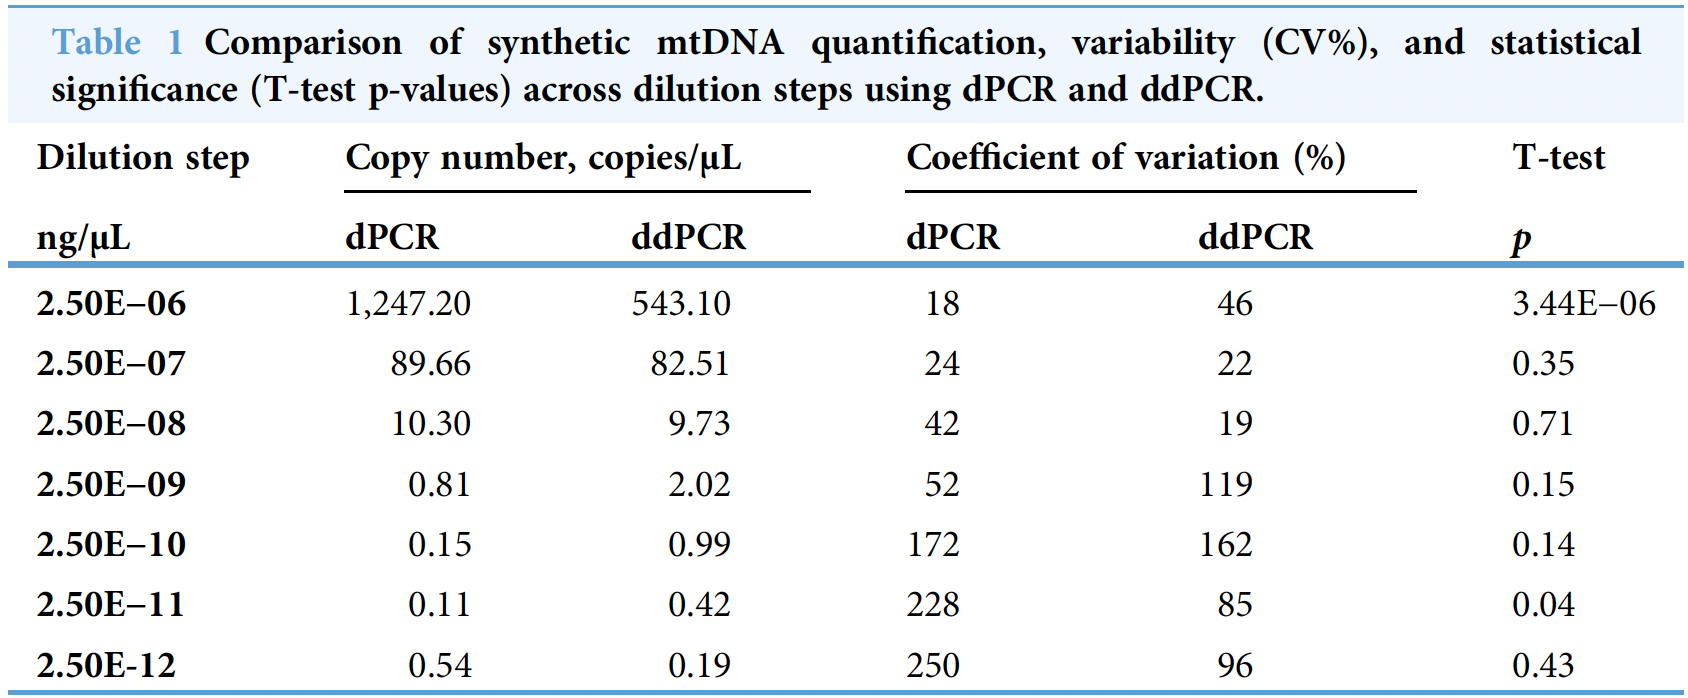


In [2]:
# Dilution steps (ng/ul)
Concentrations = [2.50e-6, 2.50e-7, 2.50e-8, 2.50e-9, 2.50e-10, 2.50e-11, 2.50e-12]
# Coefficient of viariations of dPCR and ddPCR under different dilution steps
CVs_table1_dPCR = [18,24,42,52,172,228,250]
log_CVs_table1_dPCR = [math.log(18),math.log(24),math.log(42),math.log(52),math.log(172),math.log(228),math.log(250)]
CVs_table1_ddPCR = [46,22,19,119,162,85,96]
log_CVs_table1_ddPCR = [math.log(46),math.log(22),math.log(19),math.log(119),math.log(162),math.log(85),math.log(96)]

### 0.2 Number of partitions of dPCR and ddPCR

In [3]:
Ks = {"d":8050, "dd":16082}

# 1. Monte carlo simulation

In [4]:
A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32


def lcg(state):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (A_LCG * state + C_LCG) % M_LCG


def uniforms(k, state):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    for i in range(k):
        state = lcg(state)
        out[i] = state / M_LCG
    return out, state

def f0_calculate(K, theta, Cs = Concentrations):
    f0_series = len(Cs) * [0.0]
    for j in range(7):
        f0_series[j] = math.exp(- Cs[j] * theta / K)
    return f0_series

def simulate(K, theta, state, in_repeats=10):
    if theta <= 0:
        return [1e6] * len(Concentrations), state
    N = len(Concentrations)
    CopyNumbers = N * [0.0]
    for i in range(N):
        CopyNumbers[i] = theta * Concentrations[i]
    p0_series = f0_calculate(K, theta, Cs = Concentrations)
    log_CVs = N * [0.0]
    for i in range(N):
        empty_partitions = in_repeats * [0]
        c_hat = in_repeats * [0.0]
        for j in range(in_repeats):
            p_random, state = uniforms(K, state)
            for a in range(K):
                if p_random[a] <= p0_series[i]:
                    empty_partitions[j] += 1
            emp = empty_partitions[j]

            if emp == 0:
                emp = 0.5
            elif emp == K:
                emp = K - 0.5
            c_hat[j] = - K * math.log(emp / K)
        mean = statistics.mean(c_hat)
        pstdev = statistics.pstdev(c_hat)
        if mean <= 0 or pstdev <= 0:
            cv = 1e-6
        else:
            cv = (pstdev / mean) * 100
            if cv <= 0:
                cv = 1e-6
        log_CVs[i] = math.log(cv)
    return log_CVs, state

# 2. Back forward process

In [5]:
def distance_calculate(log_CV, log_CVs_table1):
    distance = 0.0
    for i in range(7):
        distance += 1/7 * (abs(log_CV[i] - log_CVs_table1[i]))
    return distance

def tolerance_calculate(K, theta_pref, state, log_CVs_table1, out_repeats):
    distances = 0.0
    for i in range(out_repeats):
        log_CV_simulated, state = simulate(K, theta_pref, state, in_repeats=10)
        distances += distance_calculate(log_CV_simulated, log_CVs_table1)
    epsilon = (distances / out_repeats) * 1.05
    return epsilon, state

def abc_mcmc(steps, epsilon, delta, start, state, K, log_CVs_table1):
    theta = start
    chain = [0.0] * steps
    for i in range(steps):
        state = lcg(state)
        r = state / M_LCG
        proposal = theta + (2 * r - 1) * delta
        chain[i] = theta
        if proposal <= 0:
            continue
        else:
            log_CV_simulated, state = simulate(K, proposal, state, in_repeats=10)
            distance = distance_calculate(log_CV_simulated, log_CVs_table1)
            if distance <= epsilon:
                theta = proposal
    return chain, state

In [ ]:
theta_pref_dPCR = 7.9e8
theta_pref_ddPCR = 7.9e8

SEED = 2026
current_state = SEED

#epsilon_dPCR, current_state = tolerance_calculate(Ks["d"], theta_pref_dPCR, current_state, log_CVs_table1_dPCR, out_repeats=30)
epsilon_ddPCR, current_state = tolerance_calculate(Ks["dd"], theta_pref_ddPCR, current_state, log_CVs_table1_ddPCR, out_repeats=30)

STEPS = 6000
#chain_d, current_state = abc_mcmc(STEPS, epsilon_dPCR, 1e7, theta_pref_dPCR, current_state, Ks["d"], log_CVs_table1_dPCR)
chain_dd, current_state = abc_mcmc(STEPS, epsilon_ddPCR, 1e8, theta_pref_ddPCR, current_state, Ks["dd"], log_CVs_table1_ddPCR)


# 3. Visualization


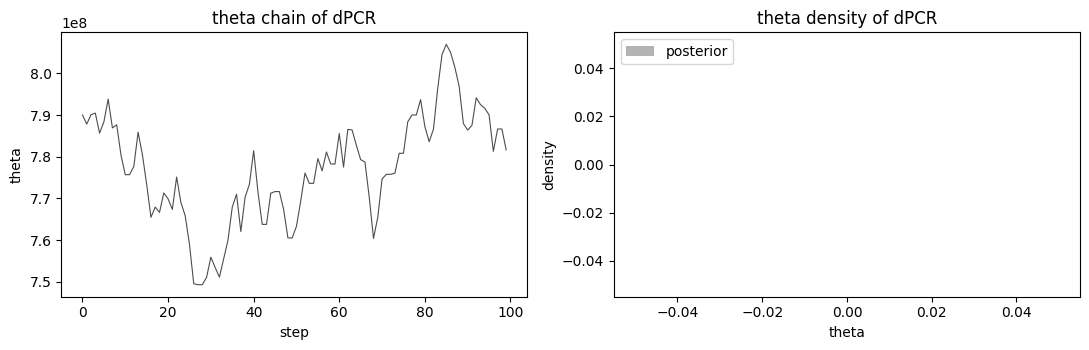

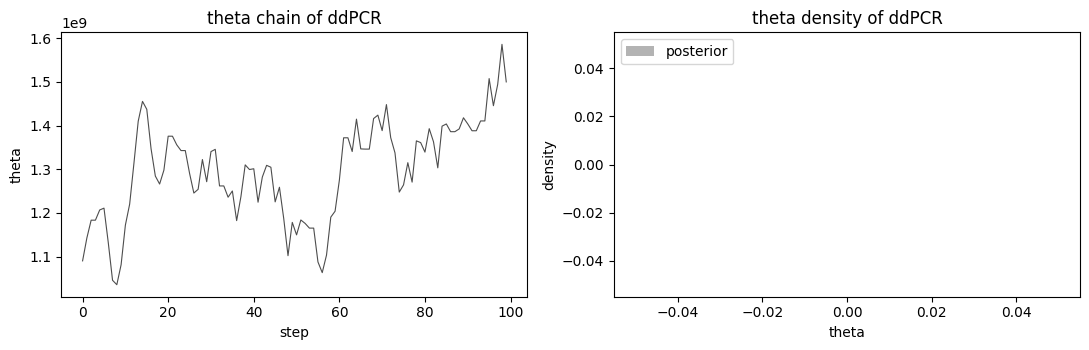

In [10]:
BURN = 300
posterior_sample_d = chain_d[BURN:]
posterior_sample_dd = chain_dd[BURN:]

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.plot(range(STEPS), chain_d, color="0.3", linewidth=0.8)
ax1.set_xlabel("step")
ax1.set_ylabel("theta")
ax1.set_title("theta chain of dPCR")

ax2.hist(posterior_sample_d, bins=30, density=True, color="0.7", label="posterior")
ax2.set_xlabel("theta")
ax2.set_ylabel("density")
ax2.set_title("theta density of dPCR")
ax2.legend()

fig1.tight_layout()

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(11, 3.6))

ax3.plot(range(STEPS), chain_dd, color="0.3", linewidth=0.8)
ax3.set_xlabel("step")
ax3.set_ylabel("theta")
ax3.set_title("theta chain of ddPCR")

ax4.hist(posterior_sample_dd, bins=30, density=True, color="0.7", label="posterior")
ax4.set_xlabel("theta")
ax4.set_ylabel("density")
ax4.set_title("theta density of ddPCR")
ax4.legend()

fig2.tight_layout()

#plt.show()
display(fig1)
display(fig2)